## Beta calibration

### Imports

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from datasets import load_dataset
from tqdm import tqdm

sys.path.append("../services/")
from index import Index, IndexDataset
from metric_funcs import calculate_ece_adaptive_bins
from process_funcs import retrieve_answer_token_index

/home/nikita/proga/Diplom/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Preparation

In [2]:
torch.random.manual_seed(42)

dataset = load_dataset("TIGER-Lab/MMLU-Pro", split="test").select(range(12000))
index = Index("../index_data/qwen2.5-7B_MMLU-PRO_launch_12000")

In [3]:
PAD_VAL = 0

VOCAB_SIZE = 20
split_val = len(index) // 2


def process_elements(xs: np.array, ys: np.array):
    processed = {}

    allowed_ids = []
    for i, x in enumerate(xs):
        # Ignoring responses where answer token distribution doesn't have all 0-9 tokens
        log = x["logprobs"][retrieve_answer_token_index(x["logprobs"])]
        if (
            len(
                set([str(x) for x in range(10)]).intersection(
                    set([x["token"] for x in log["top_logprobs"]])
                )
            )
            < 10
        ):
            continue
        allowed_ids.append(i)

    xs = xs[allowed_ids]
    ys = ys[allowed_ids]

    logits = torch.zeros((len(xs), VOCAB_SIZE))
    targets = torch.zeros(len(ys), dtype=torch.long)

    for i, (x, y) in enumerate(zip(xs, ys)):
        answer_token_index = retrieve_answer_token_index(x["logprobs"])
        answer_top_logprobs_tokens = [
            v["token"]
            for v in x["logprobs"][answer_token_index]["top_logprobs"]
        ]
        answer_top_logprobs = torch.tensor(
            [
                v["logprob"]
                for v in x["logprobs"][answer_token_index]["top_logprobs"]
            ]
        )
        max_logprob = answer_top_logprobs.max()
        norm_top_logprobs = answer_top_logprobs - max_logprob

        logits[i] = norm_top_logprobs
        targets[i] = torch.tensor(
            answer_top_logprobs_tokens.index(str(y["answer_index"])),
            dtype=torch.long,
        )

    processed["logits"] = logits
    processed["targets"] = targets

    return processed

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train = IndexDataset(
    index, dataset, process_elements, split="train", load_all_data=True
)
val = IndexDataset(
    index, dataset, process_elements, split="val", load_all_data=True
)
test = IndexDataset(
    index, dataset, process_elements, split="test", load_all_data=True
)

In [5]:
val_data = val.get()
test_data = test.get()

### Beta calibration

In [6]:
# Module which will learn parameters for beta calibration on right answers for llm


class BetaCalibration(nn.Module):
    def __init__(self, device=device):
        super().__init__()

        self.log_a = nn.Parameter(torch.tensor(0.0, device=device))
        self.log_b = nn.Parameter(torch.tensor(0.0, device=device))
        self.c = nn.Parameter(torch.tensor(0.0, device=device))
        self.eps = 1e-6

    def forward(self, probs):
        probs = torch.clamp(probs, self.eps, 1 - self.eps)

        a = torch.exp(torch.clamp(self.log_a, -5, 5))
        b = torch.exp(torch.clamp(self.log_b, -5, 5))

        calibrated_probs = torch.sigmoid(
            self.c + a * torch.log(probs) - b * torch.log(1 - probs)
        )

        return calibrated_probs

    def calibrate(self, probs):
        self.eval()
        with torch.no_grad():
            return self.forward(probs).cpu()

In [7]:
# Function to fit temperature value


def fit_beta_calibration(
    train_data,
    test_data=None,
    lr_max=1e-2,
    lr_min=1e-4,
    batch_size=8,
    epochs=3,
    plot_interval=3,
):
    beta_model = BetaCalibration(device)
    optimizer = torch.optim.Adam(beta_model.parameters(), lr_max)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, len(train_data) // batch_size, lr_min
    )

    train_losses = []
    test_losses = []
    iterations = []

    iteration_counter = 0

    for _ in tqdm(range(epochs)):
        for start in range(0, len(train_data) - batch_size, batch_size):
            batch_data = train_data.get(start, start + batch_size)
            if not batch_data:
                continue

            eps = 1e-4
            optimizer.zero_grad()
            batch_logits = batch_data["logits"].view(-1, VOCAB_SIZE).to(device)
            batch_labels = batch_data["targets"].view(-1).to(device)

            batch_probs = torch.softmax(batch_logits, dim=1)

            predictions = batch_probs.argmax(dim=1)
            pred_probs = batch_probs[
                torch.arange(len(predictions)), predictions
            ]
            targets = (predictions == batch_labels).to(torch.float32)

            train_calibrated_probs = beta_model(pred_probs)
            train_loss = torch.nn.functional.binary_cross_entropy(
                train_calibrated_probs, targets
            )

            train_loss.backward()
            optimizer.step()
            scheduler.step()

            if (
                test_data is not None
                and iteration_counter % plot_interval == 0
            ):
                train_loss = train_loss.item()
                train_losses.append(train_loss)

                test_batch = test_data.get(0, min(batch_size, len(test_data)))
                if test_batch:
                    test_logits = (
                        test_batch["logits"].view(-1, VOCAB_SIZE).to(device)
                    )
                    test_labels = test_batch["targets"].view(-1).to(device)
                    with torch.no_grad():
                        test_probs = torch.softmax(test_logits, dim=1)
                        test_probs = torch.clamp(test_probs, eps, 1 - eps)
                        test_calibrated_probs = beta_model(test_probs)
                        test_loss = torch.nn.functional.nll_loss(
                            torch.log(test_calibrated_probs), test_labels
                        )
                        test_losses.append(test_loss.item())
                    iterations.append(iteration_counter)

            iteration_counter += 1

    if len(iterations) > 0:
        plt.figure(figsize=(10, 6))
        plt.plot(iterations, train_losses, label="Train Loss", marker="o")
        if len(test_losses) > 0:
            plt.plot(iterations, test_losses, label="Test Loss", marker="s")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title("Training and Test Loss over Iterations")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return beta_model, [x for x in beta_model.named_parameters()]

## Calibration

### FInding the best temperature on validation data


Trial 1/15: lr_max=0.001000, lr_min=0.000010, batch_size=32, epochs=5


100%|██████████| 5/5 [00:05<00:00,  1.06s/it]


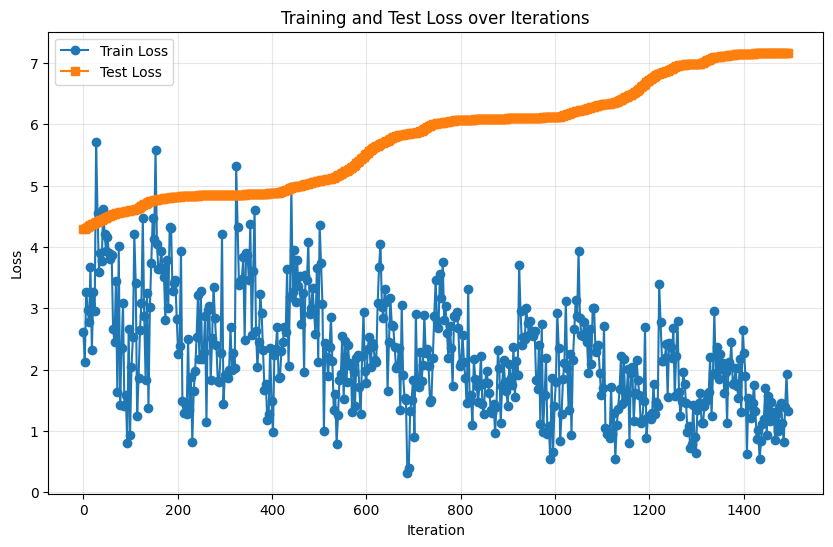

/tmp/ipykernel_50411/4019854482.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.stack([torch.tensor(x) for x in train_calibrated_probs]), torch.stack([torch.tensor(x) for x in val_data["targets"]]), verbose=True


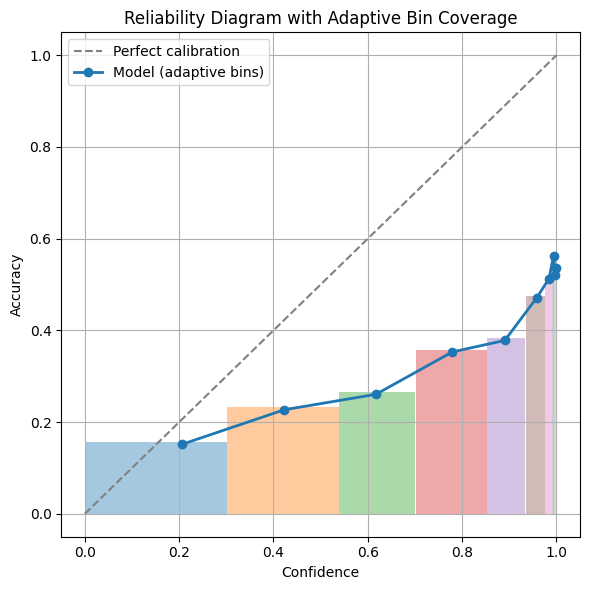

Beta parameters: log_a=0.4528 log_b=-0.6114 c=-0.6777, ECE: 0.388021

Trial 2/15: lr_max=0.000100, lr_min=0.000100, batch_size=32, epochs=5


100%|██████████| 5/5 [00:02<00:00,  1.89it/s]


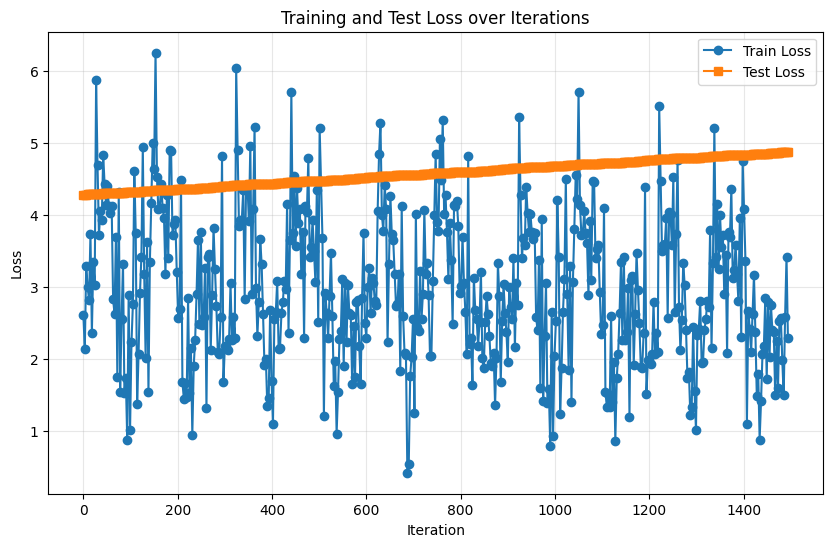

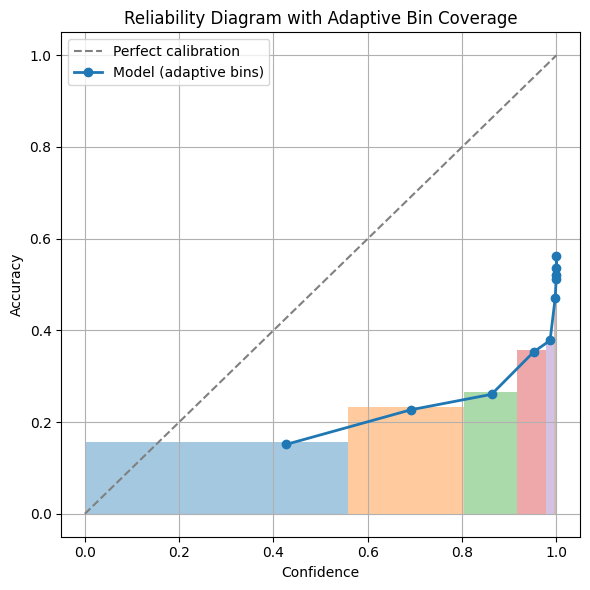

Beta parameters: log_a=0.1135 log_b=-0.1352 c=-0.1411, ECE: 0.494134

Trial 3/15: lr_max=0.010000, lr_min=0.000010, batch_size=32, epochs=5


100%|██████████| 5/5 [00:02<00:00,  1.92it/s]


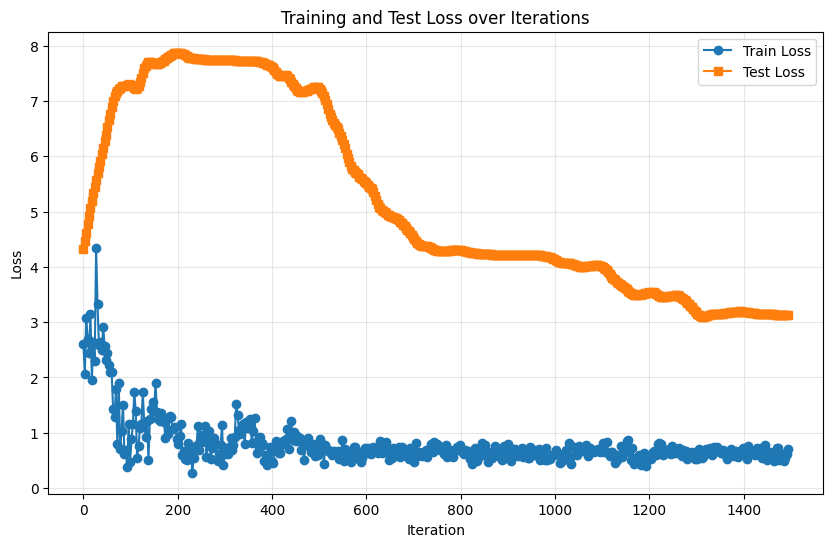

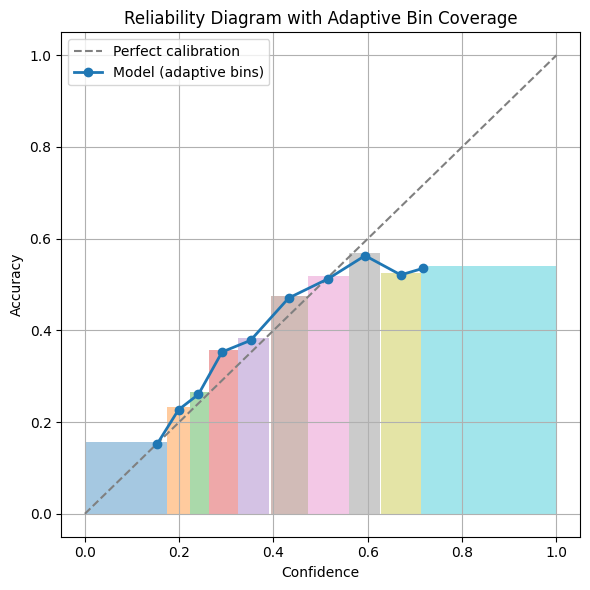

Beta parameters: log_a=-0.8371 log_b=-1.7189 c=-1.5403, ECE: 0.055066

Trial 4/15: lr_max=0.000500, lr_min=0.000001, batch_size=32, epochs=5


100%|██████████| 5/5 [00:02<00:00,  2.07it/s]


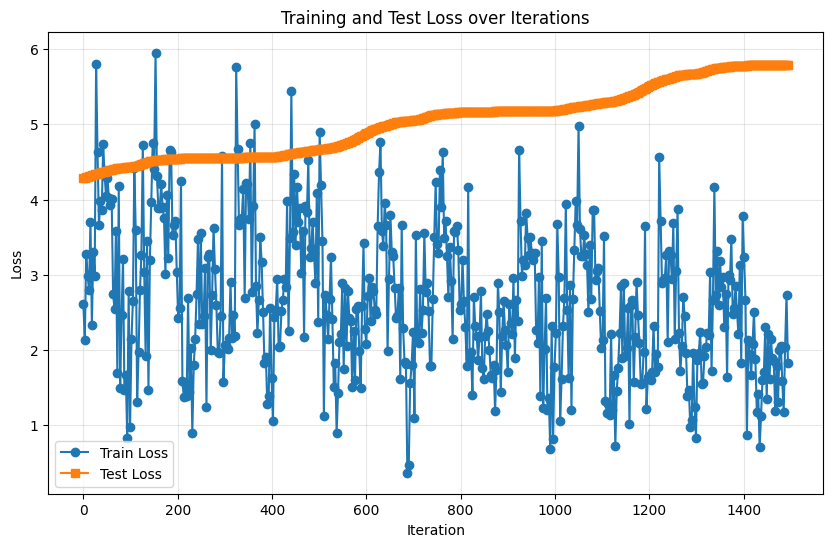

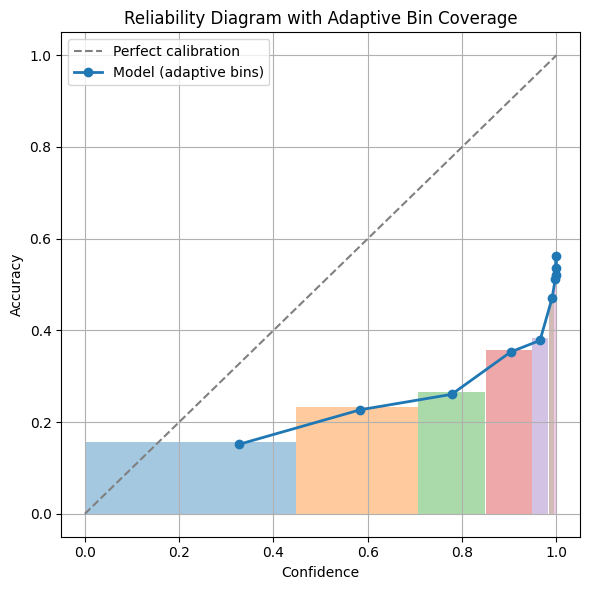

Beta parameters: log_a=0.2648 log_b=-0.3271 c=-0.3482, ECE: 0.457193

Trial 5/15: lr_max=0.005000, lr_min=0.000010, batch_size=32, epochs=5


100%|██████████| 5/5 [00:02<00:00,  1.93it/s]


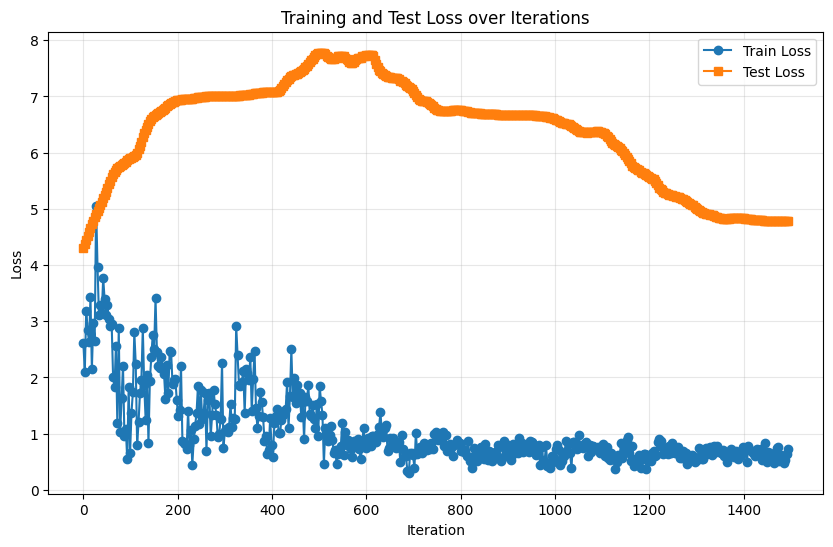

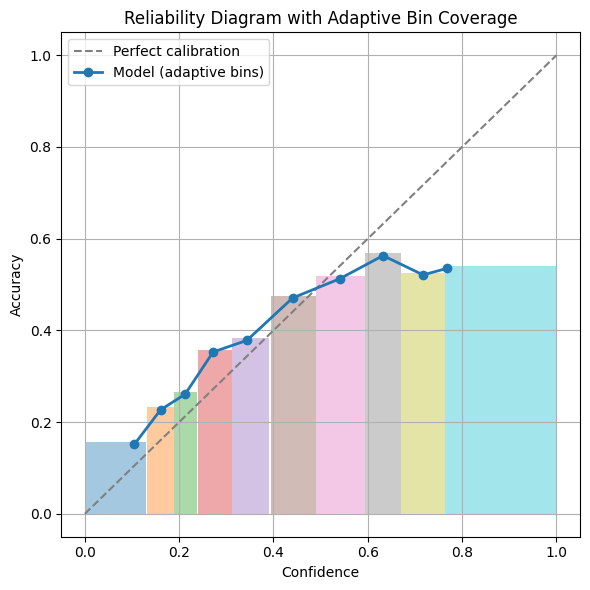

Beta parameters: log_a=-0.2357 log_b=-1.5409 c=-1.7537, ECE: 0.084317

Trial 6/15: lr_max=0.005000, lr_min=0.000100, batch_size=32, epochs=5


100%|██████████| 5/5 [00:02<00:00,  2.19it/s]


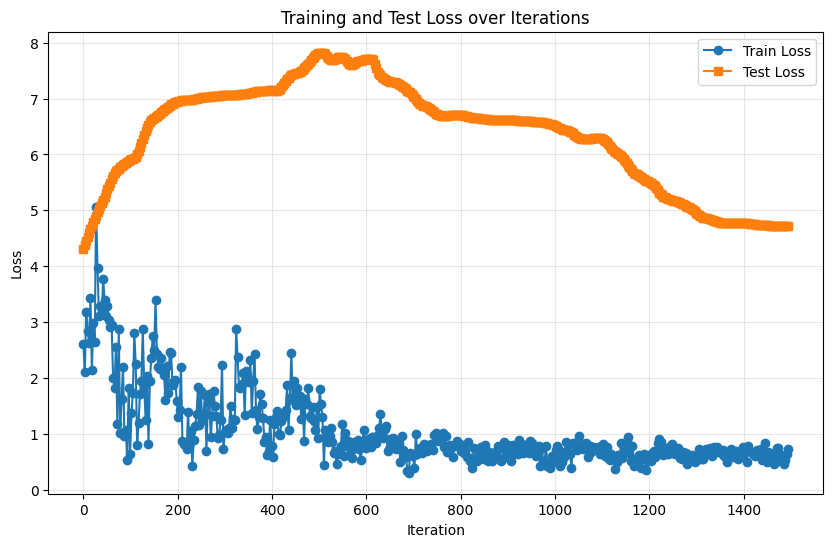

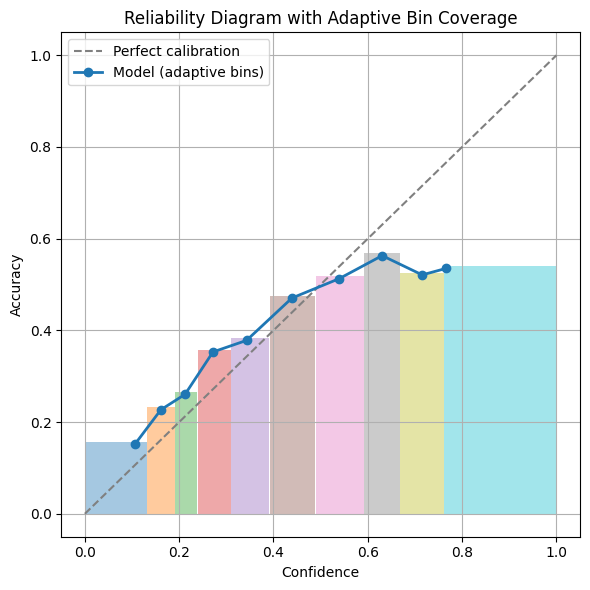

Beta parameters: log_a=-0.2540 log_b=-1.5448 c=-1.7527, ECE: 0.083659

Trial 7/15: lr_max=0.001000, lr_min=0.000005, batch_size=32, epochs=5


100%|██████████| 5/5 [00:02<00:00,  2.05it/s]


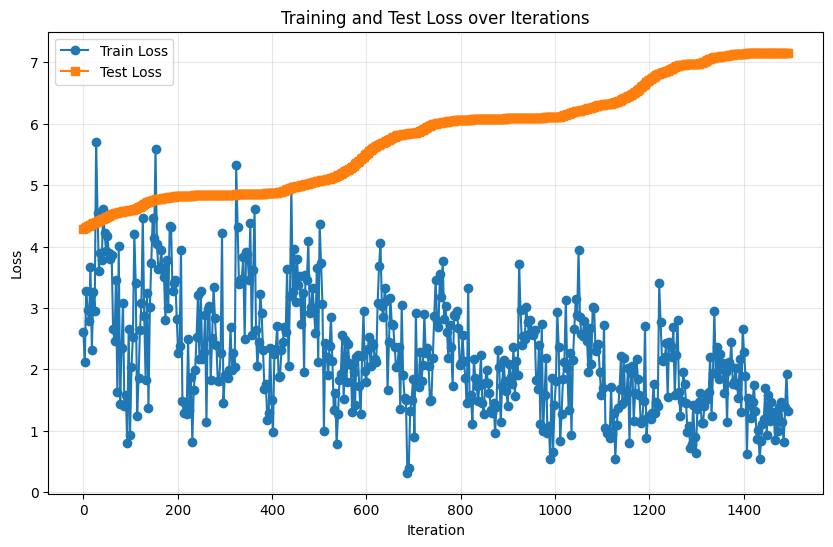

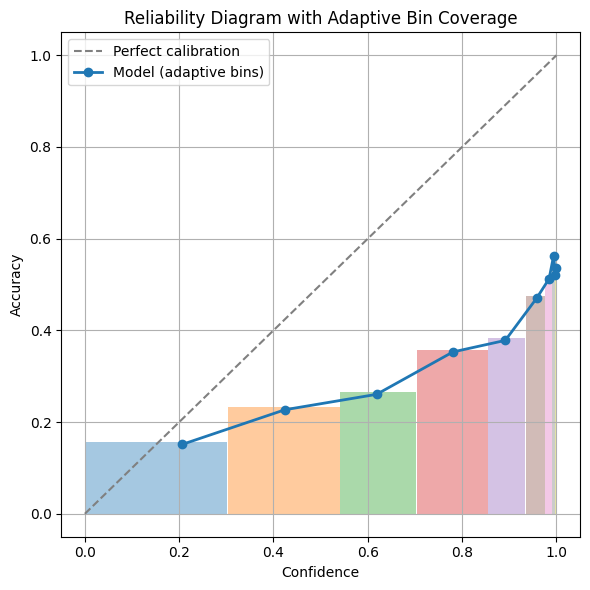

Beta parameters: log_a=0.4515 log_b=-0.6089 c=-0.6746, ECE: 0.388718

Trial 8/15: lr_max=0.001000, lr_min=0.000010, batch_size=32, epochs=5


100%|██████████| 5/5 [00:02<00:00,  1.90it/s]


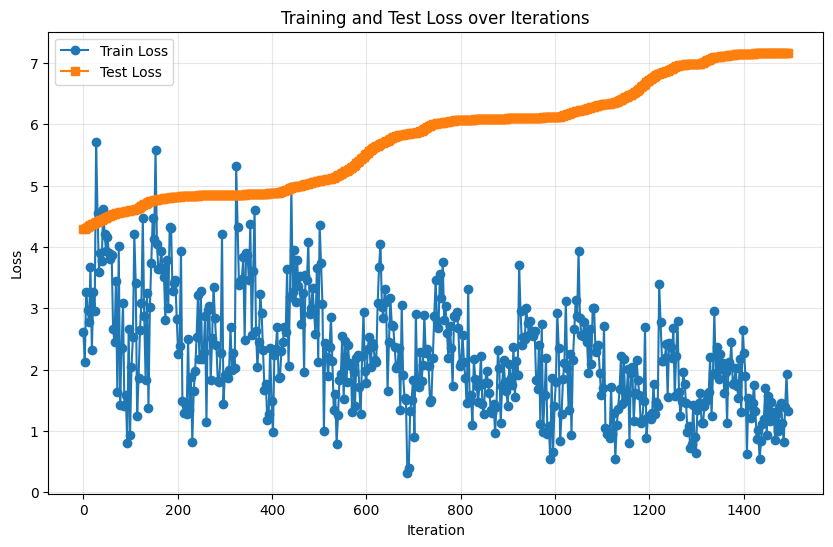

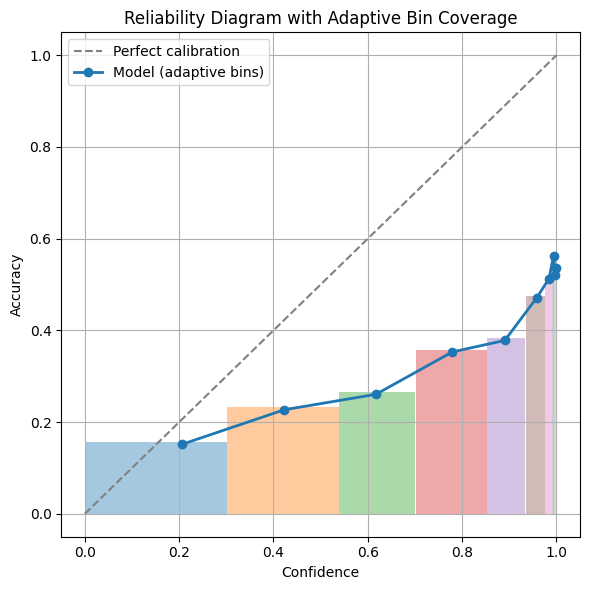

Beta parameters: log_a=0.4528 log_b=-0.6114 c=-0.6777, ECE: 0.388021

Trial 9/15: lr_max=0.000500, lr_min=0.000100, batch_size=32, epochs=5


100%|██████████| 5/5 [00:02<00:00,  1.70it/s]


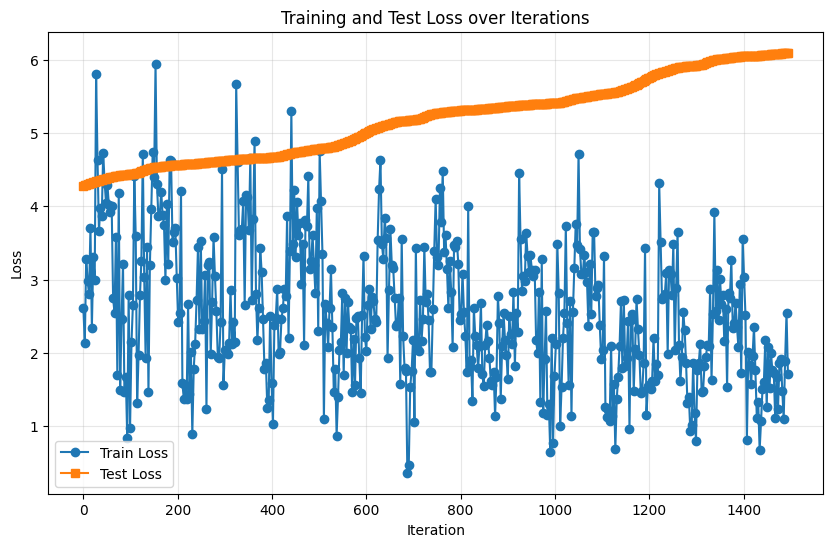

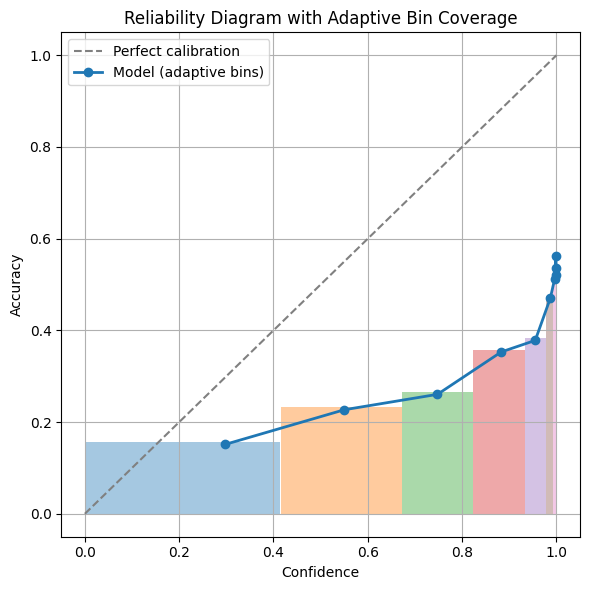

Beta parameters: log_a=0.3110 log_b=-0.3846 c=-0.4141, ECE: 0.444420

Trial 10/15: lr_max=0.001000, lr_min=0.000010, batch_size=32, epochs=5


100%|██████████| 5/5 [00:02<00:00,  1.91it/s]


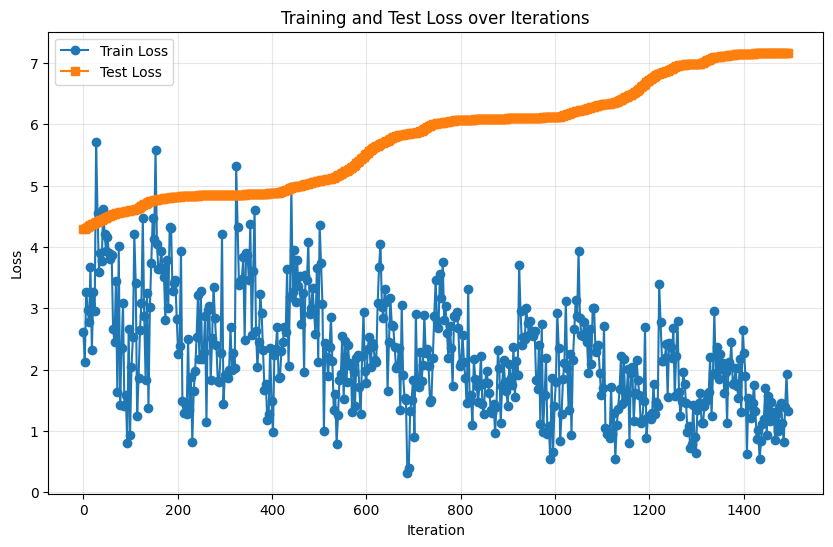

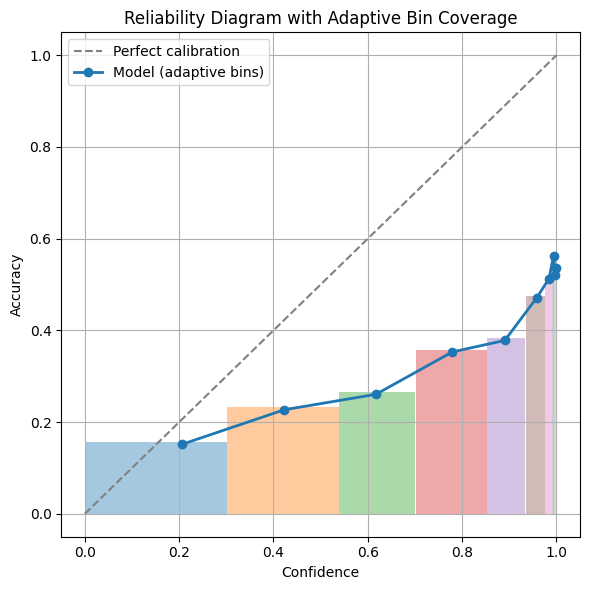

Beta parameters: log_a=0.4528 log_b=-0.6114 c=-0.6777, ECE: 0.388021

Trial 11/15: lr_max=0.000500, lr_min=0.000100, batch_size=32, epochs=5


100%|██████████| 5/5 [00:02<00:00,  2.07it/s]


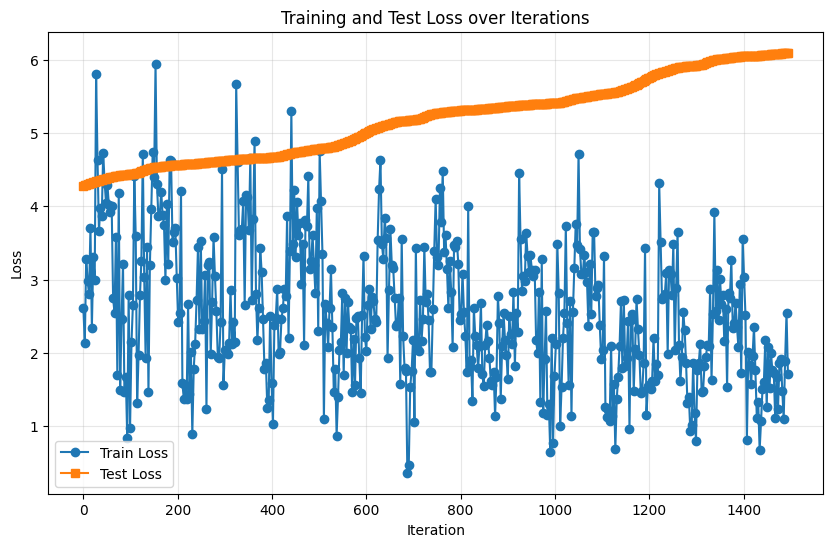

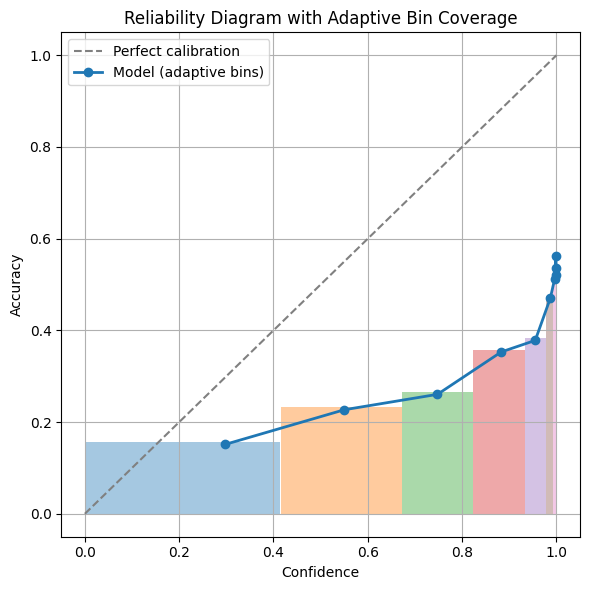

Beta parameters: log_a=0.3110 log_b=-0.3846 c=-0.4141, ECE: 0.444420

Trial 12/15: lr_max=0.001000, lr_min=0.000100, batch_size=32, epochs=5


100%|██████████| 5/5 [00:05<00:00,  1.04s/it]


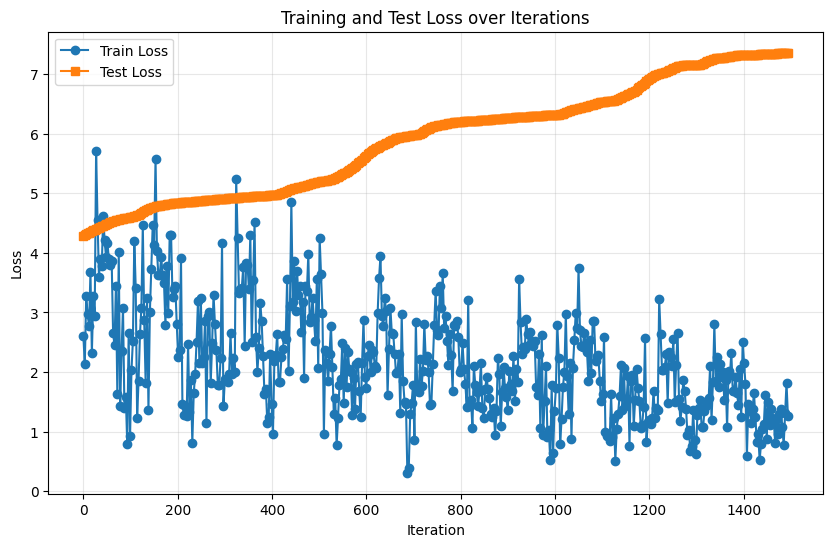

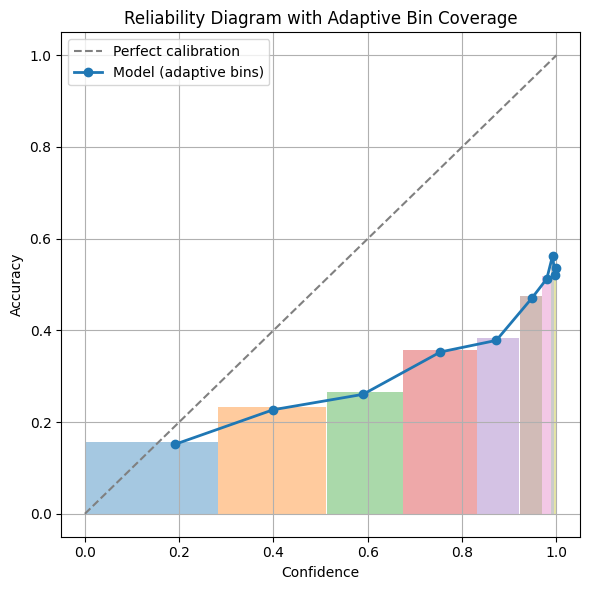

Beta parameters: log_a=0.4751 log_b=-0.6556 c=-0.7325, ECE: 0.375440

Trial 13/15: lr_max=0.001000, lr_min=0.000010, batch_size=32, epochs=5


100%|██████████| 5/5 [00:03<00:00,  1.57it/s]


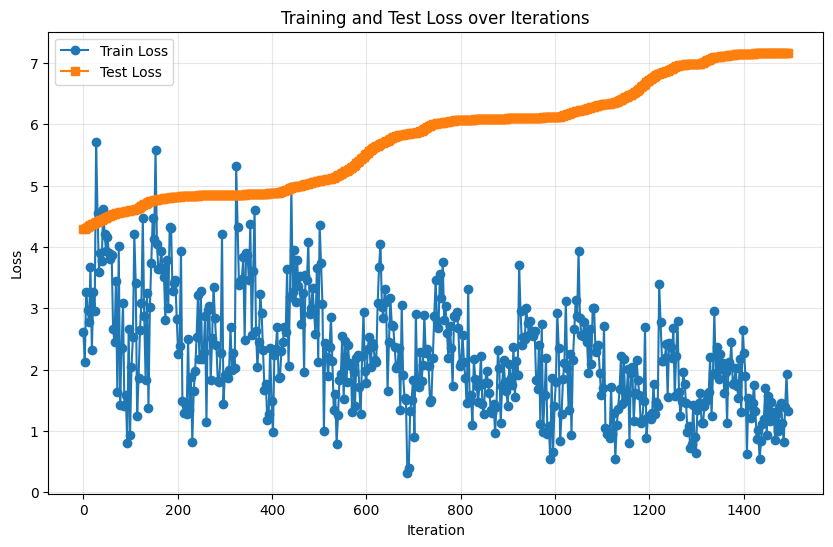

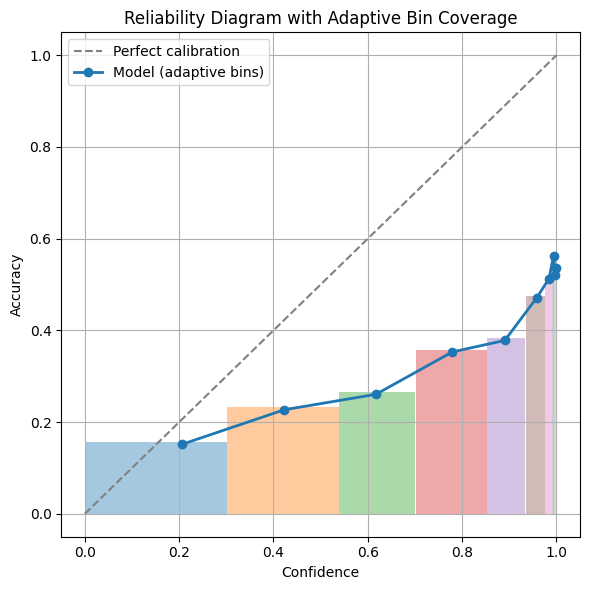

Beta parameters: log_a=0.4528 log_b=-0.6114 c=-0.6777, ECE: 0.388021

Trial 14/15: lr_max=0.000100, lr_min=0.000001, batch_size=32, epochs=5


100%|██████████| 5/5 [00:03<00:00,  1.55it/s]


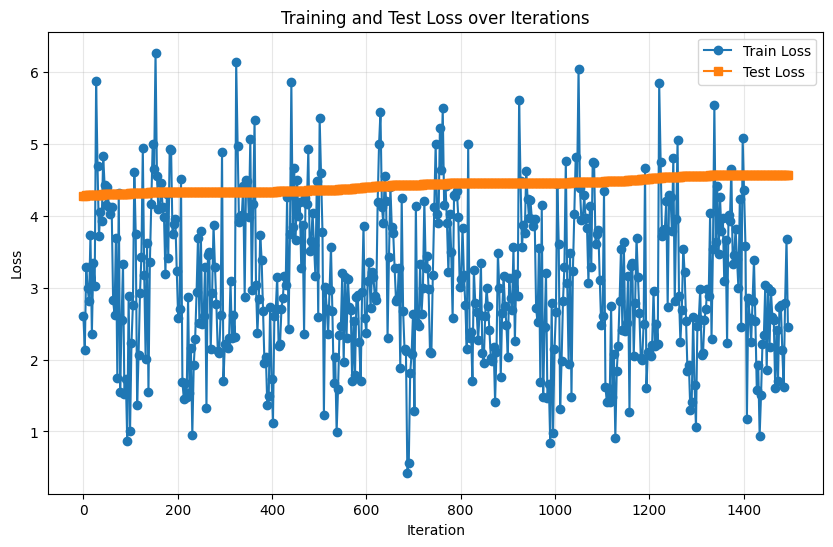

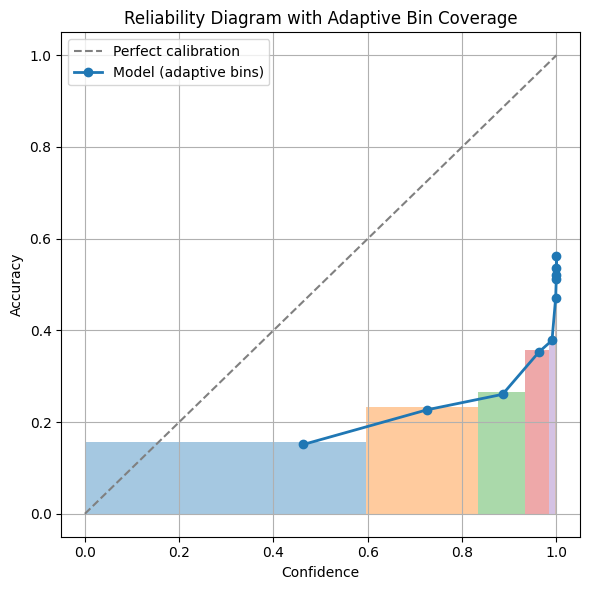

Beta parameters: log_a=0.0572 log_b=-0.0700 c=-0.0717, ECE: 0.505188

Trial 15/15: lr_max=0.005000, lr_min=0.000010, batch_size=32, epochs=5


100%|██████████| 5/5 [00:02<00:00,  1.74it/s]


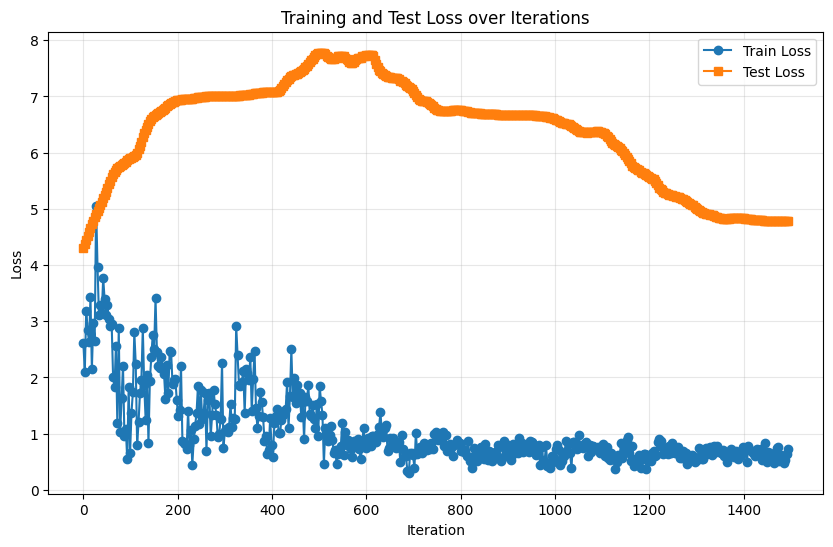

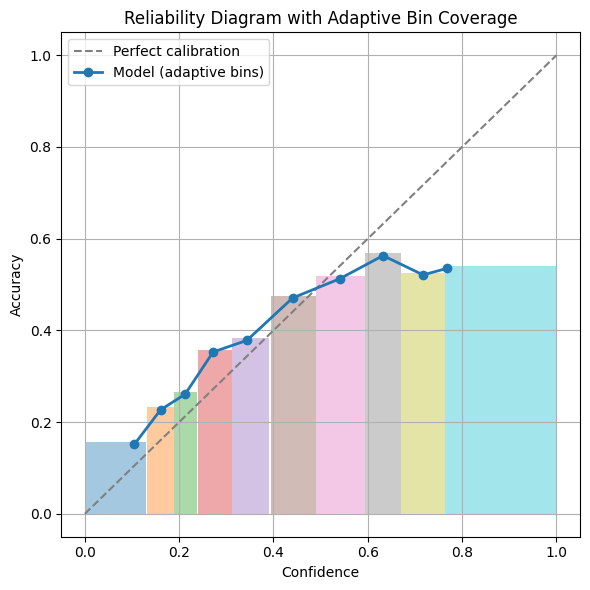

Beta parameters: log_a=-0.2357 log_b=-1.5409 c=-1.7537, ECE: 0.084317

Best ECE on: 0.055066
Best parameters: {'lr_max': np.float64(0.01), 'lr_min': np.float64(1e-05), 'batch_size': 32, 'epochs': 5}
Best parameters: log_a=-0.8371 log_b=-1.7189 c=-1.5403, ECE: 0.084317


In [15]:
TRIALS = 15

bet_model = None
results = []

for trial in range(TRIALS):
    lr_max = np.random.choice([1e-2, 5e-3, 1e-3, 5e-4, 1e-4])
    lr_min = np.random.choice([1e-4, 5e-5, 1e-5, 5e-6, 1e-6])
    batch_size = 32
    epochs = 5

    print(
        f"\nTrial {trial + 1}/{TRIALS}: lr_max={lr_max:.6f}, lr_min={lr_min:.6f}, batch_size={batch_size}, epochs={epochs}"
    )

    beta_model, beta_params = fit_beta_calibration(
        train,
        val,
        lr_max=lr_max,
        lr_min=lr_min,
        batch_size=batch_size,
        epochs=epochs,
    )

    train_calibrated_probs = beta_model.calibrate(
        torch.softmax(val_data["logits"].clone().detach().to(device), dim=1)
    )
    ece = calculate_ece_adaptive_bins(
        torch.stack([torch.tensor(x) for x in train_calibrated_probs]), torch.stack([torch.tensor(x) for x in val_data["targets"]]), verbose=True
    )

    results.append(
        {
            "params": {
                "lr_max": lr_max,
                "lr_min": lr_min,
                "batch_size": batch_size,
                "epochs": epochs,
            },
            "parameters": beta_params,
            "ece": ece,
        }
    )

    print(
        f"Beta parameters: {' '.join([f'{x[0]}={x[1].item():.4f}' for x in beta_model.named_parameters()])}, ECE: {ece:.6f}"
    )

best_result = min(results, key=lambda x: x["ece"])

print("\n" + "=" * 60)
print(f"Best ECE on: {best_result['ece']:.6f}")
print(f"Best parameters: {best_result['params']}")
print(
    f"Best parameters: {' '.join([f'{x[0]}={x[1].item():.4f}' for x in best_result['parameters']])}, ECE: {ece:.6f}"
)

### Results

In [16]:
beta_model = BetaCalibration()
beta_model.log_a, beta_model.log_b, beta_model.c = [
    x[1] for x in best_result["parameters"]
]

In [17]:
calibrated_test_answers_probs = beta_model.calibrate(
    torch.softmax(test_data["logits"].clone().detach().to(device), dim=1)
)

not_calibrated_test_answers_probs = torch.stack(
    [torch.softmax(x, dim=0) for x in test_data["logits"]]
)

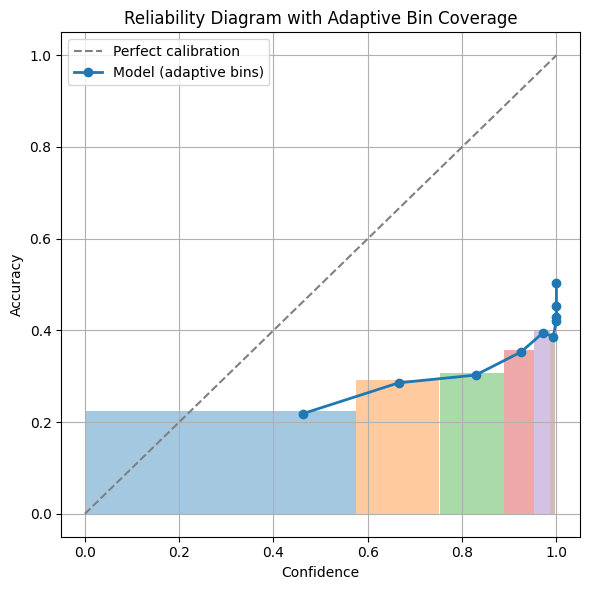

ECE on NON calibrated answer (test data): 0.5097677111625671


In [18]:
print(
    f"ECE on NON calibrated answer (test data): {calculate_ece_adaptive_bins(not_calibrated_test_answers_probs, test_data['targets'], verbose=True)}"
)

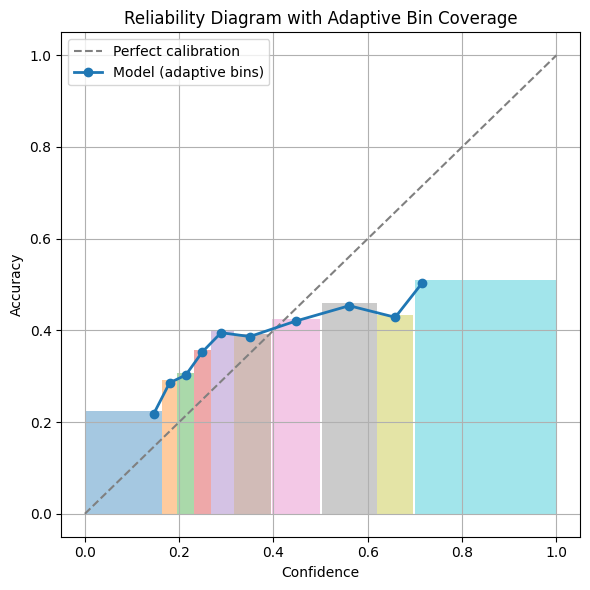

ECE on calibrated answer (test data): 0.10949540138244629


In [19]:
print(
    f"ECE on calibrated answer (test data): {calculate_ece_adaptive_bins(calibrated_test_answers_probs, test_data['targets'], verbose=True)}"
)

tensor([9.9886e-01, 1.0002e-03, 1.3908e-04, 1.6672e-06, 1.1507e-06, 1.0192e-06,
        4.1051e-07, 7.4129e-08, 7.2916e-08, 2.9681e-08, 9.1515e-09, 4.4803e-09,
        3.7689e-09, 2.2292e-09, 1.2425e-09, 1.0467e-09, 7.5897e-10, 6.3310e-10,
        5.5670e-10, 5.2531e-10])


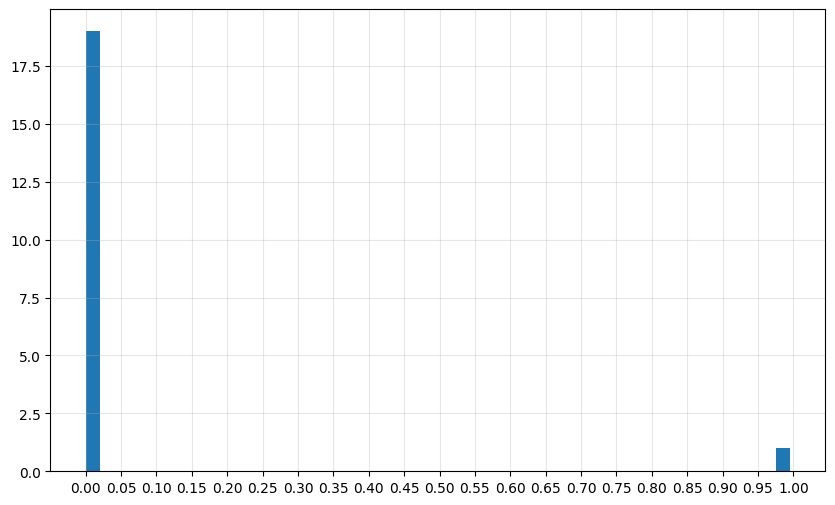

In [20]:
plt.figure(figsize=(10, 6))
plt.hist(not_calibrated_test_answers_probs[1], bins=50)
plt.xticks(np.arange(0.0, 1.001, 5e-2))
plt.grid(True, alpha=0.3)
print(not_calibrated_test_answers_probs[8])
plt.show()

tensor([0.4191, 0.0107, 0.0046, 0.0007, 0.0006, 0.0005, 0.0005, 0.0005, 0.0005,
        0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005,
        0.0005, 0.0005])


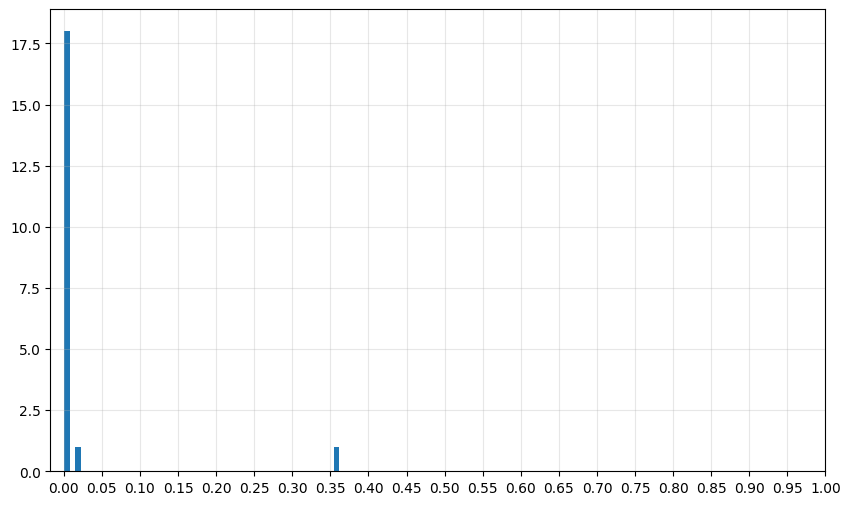

In [21]:
plt.figure(figsize=(10, 6))
plt.hist(calibrated_test_answers_probs[1], bins=50)
plt.xticks(np.arange(0.0, 1.001, 5e-2))
plt.grid(True, alpha=0.3)
print(calibrated_test_answers_probs[8])
plt.show()

In [22]:
accuracies = (
    not_calibrated_test_answers_probs.argmax(dim=-1) == test_data["targets"]
).to(torch.float)
print(f"Accuracy on NON calibrated answer: {torch.mean(accuracies).item()}")

Accuracy on NON calibrated answer: 0.3756260573863983


In [23]:
accuracies = (
    calibrated_test_answers_probs.argmax(dim=-1) == test_data["targets"]
).to(torch.float)
print(f"Accuracy on calibrated answer: {torch.mean(accuracies).item()}")

Accuracy on calibrated answer: 0.3756260573863983
